In [142]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

In [143]:
data=pd.read_csv("/Dataset---Hate-Speech-Detection-using-Deep-Learning.csv")
data.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [144]:
data['class'].value_counts()

,count
class,
1,19190
2,4163
0,1430


In [145]:
print(data.isnull().sum())

class    0
tweet    0
dtype: int64


In [146]:
print(data.duplicated().sum())

0


In [147]:
encoder = LabelEncoder()
data["class"] = encoder.fit_transform(data["class"])

print(data.head())

   class                                              tweet
0      2  !!! RT @mayasolovely: As a woman you shouldn't...
1      1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2      1  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3      1  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4      1  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [148]:
data["text_length"]=data["tweet"].apply(lambda x: len(x.split()))
print("Maximum length:",data["text_length"].max())
print("Minimum length:",data["text_length"].min())
print("Average length:",data["text_length"].mean())

data.sort_values(
    by="text_length",
    ascending=False
)[["tweet" , "text_length"]].head(10)

Maximum length: 52
Minimum length: 1
Average length: 14.117015696243392


,tweet,text_length
22478,Was finna slit my eyebrows up in the shop but ...,52
2099,"' She herd I was a dope boy , I herd she was a...",36
11383,"I'm sippin on Patron nigga , my bitch bad to t...",33
13699,"Oomf a hoe. She know she a hoe, I know she a h...",33
10377,I got no pic up lines I stay on my grind I tel...,33
19115,RT @hspiotta_21: c is for cunt\nu is for ur a ...,33
23174,Yo bitch a freak fucked ha to sleep and dat wa...,33
11158,I'd shut the fuck up or I'll just be wide and ...,33
16895,"RT @PickinUpGirls: It goes from ""baby"" to ""hoe...",32
20418,RT @yung_gleesh: If rather fukk a bitch dat fu...,32


In [149]:
def clean_text(text):
  text=text.lower()
  text=re.sub(r'http\S+|www\S+','',text)
  text=re.sub(r'<.*?>','',text)
  text=re.sub(r'@\w+','',text)
  text = re.sub(r'\brt\b', '', text)
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  return text.strip()

In [150]:
data ["tweet"]=data["tweet"].apply(clean_text)

In [151]:
sentences=data["tweet"].values
labels=data["class"].values

In [152]:
x_train,x_text,y_train,y_text=train_test_split(
    sentences,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [153]:
vocab_size = 20000
oov_token = "<oov>"

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token=oov_token
)

tokenizer.fit_on_texts(x_train)

In [154]:
train_sequences = tokenizer.texts_to_sequences(x_train)
text_sequences = tokenizer.texts_to_sequences(x_text)

In [155]:
max_length=30
x_train_pad = pad_sequences(
    train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)
x_text_pad = pad_sequences(
    text_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [156]:
embedding_dim = 100

model = Sequential([
    Input(shape=(max_length,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    LSTM(64),
    Dropout(0.4),
    Dense(3, activation='softmax')
])


In [157]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [158]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 30, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,042,435 (7.79 MB)

 Trainable params: 2,042,435 (7.79 MB)

 Non-trainable params: 0 (0.00 B)

In [159]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

In [160]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{np.int64(0): np.float64(5.776806526806527), np.int64(1): np.float64(0.4304759423310752), np.int64(2): np.float64(1.9845845845845846)}


In [161]:
history = model.fit(
    x_train_pad,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.6536 - loss: 0.8584 - val_accuracy: 0.7900 - val_loss: 0.6922
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.7985 - loss: 0.5502 - val_accuracy: 0.7463 - val_loss: 0.6062
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8272 - loss: 0.3791 - val_accuracy: 0.8212 - val_loss: 0.4737
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8748 - loss: 0.2873 - val_accuracy: 0.8283 - val_loss: 0.5169
Epoch 5/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.9125 - loss: 0.2075 - val_accuracy: 0.8293 - val_loss: 0.4744
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


In [162]:
loss,accuracy=model.evaluate(x_text_pad,y_text)
print('loss:',loss)
print('Accuracy:',accuracy)

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8176 - loss: 0.4926
loss: 0.4926387071609497
Accuracy: 0.8176316022872925


In [163]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob =model.predict(x_text_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
if len(y_text.shape) > 1:
    y_true = np.argmax(y_text, axis=1)
else:
    y_true = y_text
print(classification_report(y_text,y_pred))

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
              precision    recall  f1-score   support

           0       0.24      0.64      0.35       286
           1       0.96      0.82      0.89      3838
           2       0.79      0.85      0.82       833

    accuracy                           0.82      4957
   macro avg       0.66      0.77      0.68      4957
weighted avg       0.89      0.82      0.84      4957



[[ 183   83   20]
 [ 507 3163  168]
 [  71   55  707]]


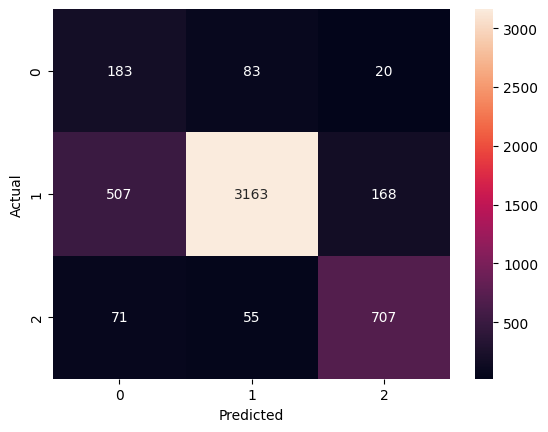

In [165]:
from matplotlib import cm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm=confusion_matrix(y_text,y_pred)
print(cm)
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [172]:
from tensorflow.keras.layers import Bidirectional
model2 = Sequential([
    Input(shape=(max_length,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=300
    ),
    Bidirectional(
        LSTM(64)
    ),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

In [173]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [176]:
history = model2.fit(
    x_train_pad,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 78s 158ms/step - accuracy: 0.8513 - loss: 0.3532 - val_accuracy: 0.8432 - val_loss: 0.4295
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 77s 155ms/step - accuracy: 0.9055 - loss: 0.2161 - val_accuracy: 0.8480 - val_loss: 0.4336
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 84s 158ms/step - accuracy: 0.9356 - loss: 0.1374 - val_accuracy: 0.8656 - val_loss: 0.4642
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [178]:
loss,accuracy=model2.evaluate(x_text_pad,y_text)
print('loss:',loss)
print('Accuracy:',accuracy)

155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8316 - loss: 0.4751
loss: 0.47510045766830444
Accuracy: 0.8315513134002686


In [179]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_prob2 = model2.predict(x_text_pad)
y_pred2 = np.argmax(y_pred_prob2, axis=1)

y_true = y_text

print(classification_report(
    y_true,
    y_pred2,
    zero_division=0
))

155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step
              precision    recall  f1-score   support

           0       0.25      0.62      0.36       286
           1       0.96      0.85      0.90      3838
           2       0.80      0.83      0.82       833

    accuracy                           0.83      4957
   macro avg       0.67      0.77      0.69      4957
weighted avg       0.89      0.83      0.85      4957



In [180]:
model2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 30, 300)        │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,561,803 (70.81 MB)

 Trainable params: 6,187,267 (23.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,374,536 (47.21 MB)